# Module 4: Brownian Motion

Brownian motion is a continuous time stochastic process with continuous paths.

It appears in many applications, including particle motion, molecular diffusion, and simple financial models.

Brownian motion is related to random walks. It is not a jump process, but it can be approximated by properly scaled random walks.

In this module, we simulate Brownian motion paths, study the distribution of $B(T)$, compare Brownian motion with scaled random walks, and use Brownian motion to model simple particle motion.

## Libraries

Run the cell below to import the libraries used in this module.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import norm

In [2]:
FIGSIZE = (8, 4.5)
SMALL_FIGSIZE = (8, 3.5)
SUBPLOT_FIGSIZE = (8, 9)

HIST_ALPHA = 0.65
OVERLAP_ALPHA = 0.45

plt.rcParams["figure.figsize"] = FIGSIZE
plt.rcParams["axes.grid"] = False
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["legend.frameon"] = False

plt.rcParams["lines.markersize"] = 4

## Example 1: Sample paths of Brownian motion

Brownian motion is usually denoted by $B(t)$, and it starts from $B(0)=0$.

For $0\le s<t$, the increment satisfies

$$
B(t)-B(s)\sim N(0,t-s).
$$

Increments over disjoint time intervals are independent, and the distribution of $B(t)-B(s)$ depends only on the interval length $t-s$, not on the starting time $s$.

To simulate a path, we choose a small time step $\Delta t$ and simulate each Brownian increment as

$$
\Delta B_k=\sqrt{\Delta t}\,Z_k,
\qquad Z_k\sim N(0,1).
$$

The simulated path is obtained by adding the increments one by one:

$$
B(t_k)=\Delta B_1+\Delta B_2+\cdots+\Delta B_k.
$$

This gives a numerical approximation of Brownian motion on a time grid.

For each fixed time $t$, Brownian motion satisfies $B(t)\sim N(0,t)$. Thus $E[B(t)]=0$ and $V[B(t)]=t$. The average position is still zero, but the variability increases with time.

In [3]:
def simulate_bm(T, dt, rng):
    """
    Simulate one Brownian motion path.

    Parameters
    ----------
    T : float
        Time horizon.
    dt : float
        Time step size.
    rng : numpy.random.Generator
        Random number generator.

    Returns
    -------
    times : numpy array
        Time points.
    B : numpy array
        Brownian motion values at the time points.
    """

    # Number of time steps
    n_steps = int(T / dt)

    # Time points
    times = np.linspace(0, T, n_steps + 1)

    # Simulate Brownian increments
    increments = np.sqrt(dt) * rng.normal(0, 1, size=n_steps)

    # Construct the simulated Brownian path by cumulative sums
    B = np.concatenate(([0], np.cumsum(increments)))

    return times, B

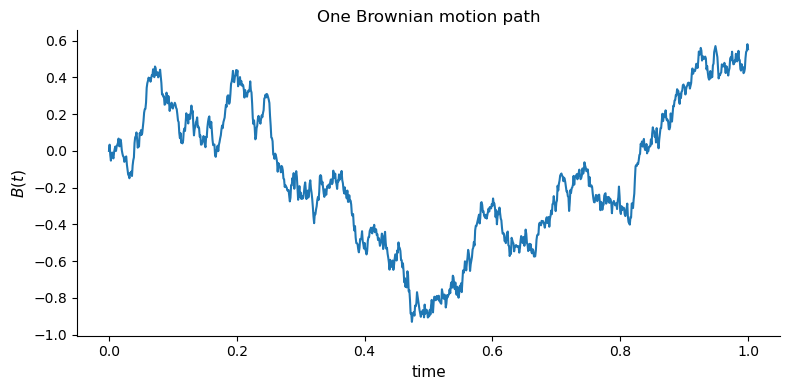

In [4]:
# Time horizon
T = 1

# Time step size
dt = 0.001

# Create a random generator
rng = np.random.default_rng()

# Simulate one Brownian motion path
times, B = simulate_bm(T, dt, rng)

# Plot one path
plt.figure(figsize=(8, 4))

plt.plot(times, B)

plt.xlabel("time")
plt.ylabel("$B(t)$")
plt.title("One Brownian motion path")
plt.tight_layout()
plt.show()

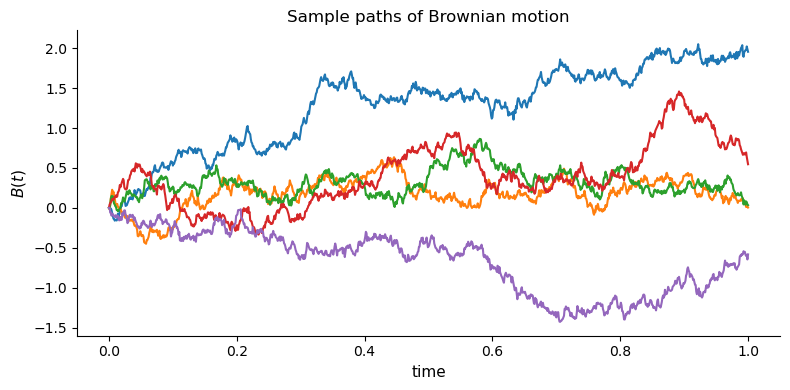

In [5]:
# Number of sample paths
n_paths = 5

# Create a random generator
rng = np.random.default_rng()

plt.figure(figsize=(8, 4))

for path in range(n_paths):
    # Simulate one Brownian motion path
    times, B = simulate_bm(T, dt, rng)

    # Plot this path
    plt.plot(times, B)

plt.xlabel("time")
plt.ylabel("$B(t)$")
plt.title("Sample paths of Brownian motion")
plt.tight_layout()
plt.show()


All paths start at $B(0)=0$. After that, they separate because the increments are random. The increasing spread is consistent with $V[B(t)]=t$.

## Example 2: Distribution of $B(T)$

Now we look at Brownian motion at one fixed time $T$. For Brownian motion,

$$
B(T)\sim N(0,T).
$$

This means $E[B(T)]=0$ and $V[B(T)]=T$.

In one simulation, we generate one Brownian motion path and record only its final value $B(T)$. We repeat this many times, so the collected final values form a simulated sample from the distribution of $B(T)$.

The histogram is then compared with the exact normal density.

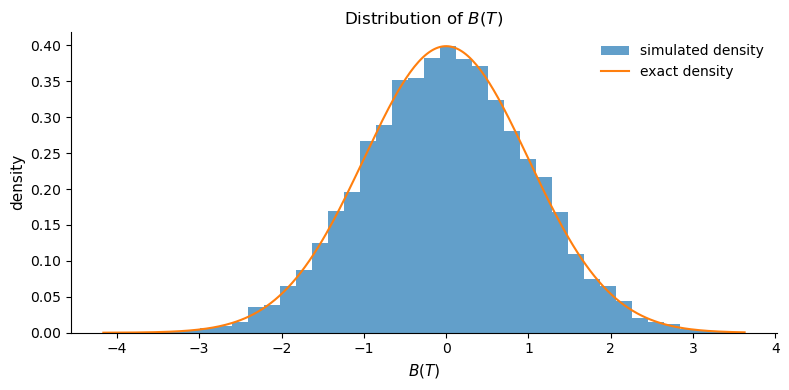

In [6]:
# Time horizon
T = 1

# Time step size
dt = 0.001

# Number of repeated simulations
N = 10000

# Create a random generator
rng = np.random.default_rng()

# Store final values B(T)
B_final = []

for run in range(N):
    # Simulate one Brownian motion path
    times, B = simulate_bm(T, dt, rng)

    # Store the final value
    B_final.append(B[-1])

# Convert to numpy array
B_final = np.array(B_final)

# Values for exact normal density
x_values = np.linspace(np.min(B_final), np.max(B_final), 300)

# Exact density of N(0,T)
density_exact = norm.pdf(x_values, loc=0, scale=np.sqrt(T))

# Plot simulated distribution and exact density
plt.figure(figsize=(8, 4))

plt.hist(
    B_final,
    bins=40,
    density=True,
    alpha=0.7,
    label="simulated density"
)

plt.plot(
    x_values,
    density_exact,
    color="C1",
    linewidth=1.5,
    label="exact density"
)

plt.xlabel("$B(T)$")
plt.ylabel("density")
plt.title("Distribution of $B(T)$")
plt.legend()
plt.tight_layout()
plt.show()

This plot shows a fixed time distribution, not a sample path. When $T=1$, the exact distribution is $B(1)\sim N(0,1)$, and the simulated histogram is close to the exact normal density.

## Example 3: Random walk approximation to Brownian motion

Brownian motion can be connected to the simple symmetric random walk. Let $X_n$ be a simple symmetric random walk,

$$
X_n=Z_1+\cdots+Z_n,
$$

where $P(Z_i=1)=P(Z_i=-1)=1/2$.

For any positive integer $n$, define the scaled process

$$
B^{(n)}(t)=\frac{X_{\lfloor nt\rfloor}}{\sqrt n},
\qquad t\geq 0.
$$

The factor $n$ changes the time scale, and the factor $\sqrt n$ changes the vertical scale. For large values of $n$, due to the central limit theorem, $B^{(n)}$ is close to a Brownian motion.

This example shows how Brownian motion can be approximated by a scaled random walk.

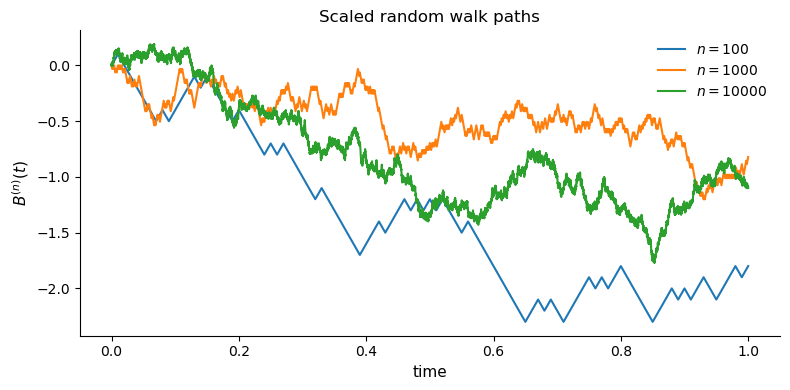

In [7]:
# Time horizon
T = 1

# Different scaling parameters
n_values = [100, 1000, 10000]

# Create a random generator
rng = np.random.default_rng()

plt.figure(figsize=(8, 4))

for n in n_values:
    # Number of discrete steps
    n_steps = int(n * T)

    # Discrete time points
    times = np.arange(n_steps + 1) / n

    # Simulate random walk steps
    steps = rng.choice([1, -1], size=n_steps, p=[0.5, 0.5])

    # Construct random walk path
    X = np.concatenate(([0], np.cumsum(steps)))

    # Scale the random walk
    B_scaled = X / np.sqrt(n)

    # Plot scaled path
    plt.plot(times, B_scaled, label=f"$n={n}$")

plt.xlabel("time")
plt.ylabel("$B^{(n)}(t)$")
plt.title("Scaled random walk paths")
plt.legend()
plt.tight_layout()
plt.show()

For small $n$, the discrete steps are more visible. For large values of $n$, the scaled random walk has Brownian motion type behaviour. At fixed times, this is related to the central limit theorem. As a process, this approximation is connected with the invariance principle.

It shows how Brownian motion can be approximated by a properly scaled random walk.

## Example 4: Particle motion in two dimensions

Brownian motion can be used as a simple model for the random motion of a small particle.

In two dimensions, we use two independent Brownian motions and write the position at time $t$ as

$$
(B_1(t),B_2(t)).
$$

The distance from the origin is

$$
R(t)=\sqrt{B_1(t)^2+B_2(t)^2}.
$$

The next plot shows one simulated two dimensional Brownian path.

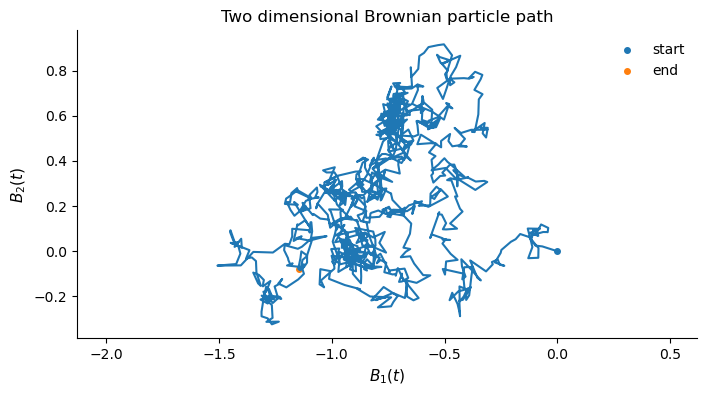

final distance from origin: 1.1472195252847506


In [8]:
# Time horizon
T = 1

# Time step size
dt = 0.001

# Create a random generator
rng = np.random.default_rng()

# Simulate two independent Brownian motion paths
times, B1 = simulate_bm(T, dt, rng)
times, B2 = simulate_bm(T, dt, rng)

# Compute distance from the origin
R = np.sqrt(B1**2 + B2**2)

# Plot the two-dimensional path
plt.figure(figsize=(8, 4))

plt.plot(B1, B2)
plt.scatter(B1[0], B2[0], label="start")
plt.scatter(B1[-1], B2[-1], label="end")

plt.xlabel("$B_1(t)$")
plt.ylabel("$B_2(t)$")
plt.title("Two dimensional Brownian particle path")
plt.legend()
plt.axis("equal")
plt.show()

print("final distance from origin:", R[-1])

This is one simulation of a two dimensional Brownian path. The curve shows the position of the particle over time, so it is a sample path in space, not a distribution.

The start and end points are marked. The final distance from the origin is random and changes if the simulation is repeated.

We can also simulate particle motion in three dimensions. In this case, the particle position is

$$
(B_1(t),B_2(t),B_3(t)),
$$

where $B_1(t)$, $B_2(t)$, and $B_3(t)$ are independent Brownian motions.

The distance from the origin is

$$
R(t)=\sqrt{B_1(t)^2+B_2(t)^2+B_3(t)^2}.
$$


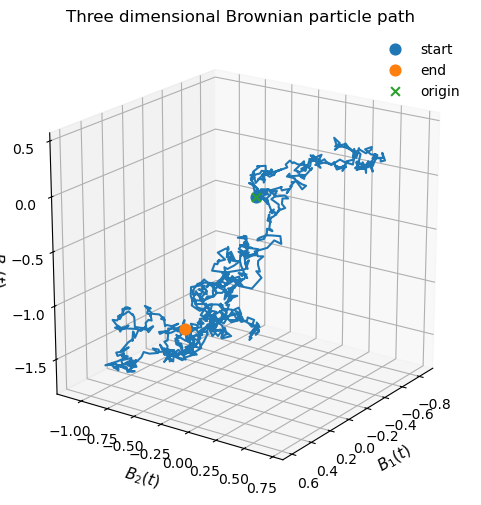

final distance from origin: 1.425679849369535


In [9]:
# Time horizon
T = 1

# Time step size
dt = 0.001

# Create a random generator
rng = np.random.default_rng()

# Simulate three independent Brownian motion paths
times, B1 = simulate_bm(T, dt, rng)
times, B2 = simulate_bm(T, dt, rng)
times, B3 = simulate_bm(T, dt, rng)

# Compute distance from the origin
R = np.sqrt(B1**2 + B2**2 + B3**2)

# Create a 3D plot
fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection="3d")

# Plot the Brownian path
ax.plot(B1, B2, B3, linewidth=1.5)

# Mark the start and end points
ax.scatter(B1[0], B2[0], B3[0], s=60, label="start")
ax.scatter(B1[-1], B2[-1], B3[-1], s=60, label="end")

# Mark the origin
ax.scatter(0, 0, 0, s=40, marker="x", label="origin")

ax.set_xlabel("$B_1(t)$")
ax.set_ylabel("$B_2(t)$")
ax.set_zlabel("$B_3(t)$")
ax.set_title("Three dimensional Brownian particle path")

ax.set_box_aspect([1, 1, 1])

ax.view_init(elev=20, azim=35)

ax.legend()
plt.show()

print("final distance from origin:", R[-1])

This is one simulation of a three dimensional Brownian path. The curve shows a spatial trajectory, not a distribution plot.

The three coordinates are independent Brownian motions. The final distance from the origin is one random outcome from this simulation.

## Example 5: A simple Brownian price model

Brownian motion is often used as a building block in simple models for asset prices.

Here we use

$$
S(t)=S_0 \exp\left(\mu t + \sigma B(t)\right),
$$

where

- $S_0$ is the initial price,
- $\mu$ controls the trend,
- $\sigma$ controls the size of the random fluctuations,
- $B(t)$ is a Brownian motion.

This is a simple simulation model.  
The goal is to compare the effect of the parameters, not to develop a full financial model.

We compare four parameter combinations:

$$
(\mu,\sigma)=(0,0.1),\ (0,0.2),\ (0.1,0.1),\ (0.1,0.2).
$$

To make the comparison clear, all four curves use the same Brownian motion path.

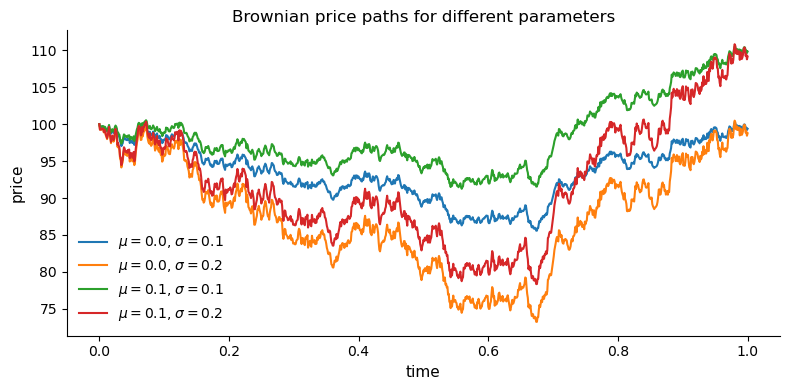

In [10]:
# Initial price
S0 = 100

# Time horizon
T = 1

# Time step size
dt = 0.001

# Create a random generator
rng = np.random.default_rng()

# Simulate one Brownian motion path
times, B = simulate_bm(T, dt, rng)

# Four parameter combinations
parameter_pairs = [
    (0.0, 0.1),
    (0.0, 0.2),
    (0.1, 0.1),
    (0.1, 0.2)
]

plt.figure(figsize=(8, 4))

for mu, sigma in parameter_pairs:
    # Compute the price path
    S = S0 * np.exp(mu * times + sigma * B)
    
    # Plot the path
    plt.plot(times, S, label=f"$\\mu={mu}$, $\\sigma={sigma}$")

plt.xlabel("time")
plt.ylabel("price")
plt.title("Brownian price paths for different parameters")
plt.legend()
plt.tight_layout()
plt.show()

In this figure, the four curves use the same Brownian motion path. This makes it easier to compare the role of the parameters.

A larger $\sigma$ gives larger random fluctuations. A larger $\mu$ gives a stronger deterministic trend in the logarithm of the price.

This is only a simple illustrative price path model. It is used to show how Brownian motion can be reused in an applied setting, not to develop a full financial model.